- load results from [scvi norm](02a_cnmf_scvi_tumor.ipynb)
- Supplementary Figure 20B,C,D,E
- Supplementary Figure 21A

In [62]:
import os
import warnings
warnings.simplefilter('ignore')
from cnmf import cNMF
import starcat

import scanpy as sc
import scanpy.external as sce
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mplscience

from scipy.cluster.hierarchy import leaves_list, linkage, dendrogram
from scipy.spatial.distance import pdist, squareform

# Run cNMF cli - tumor
- /tumor
- numpy < 2

In [ ]:
cnmf prepare --output-dir cNMF --name subcluster \
-c subcluster.h5ad --tpm subcluster_scvi.h5ad --genes-file=hvgs.txt \
-k 2 3 4 5 6 7 8 9 10 11 12 13 14 15 --n-iter 1000 --total-workers 72 --seed 777 --numgenes 2000

In [ ]:
export OMP_NUM_THREADS=1 
parallel cnmf factorize --output-dir cNMF --name subcluster --total-workers 72 --worker-index {} ::: $(seq 0 71) 

In [ ]:
cnmf combine --output-dir cNMF --name subcluster --total-workers 72

In [ ]:
cnmf k_selection_plot --output-dir cNMF --name subcluster --total-workers 72

In [ ]:
cnmf consensus --output-dir cNMF --name subcluster --components 7 --local-density-threshold 2.0 --show-clustering --total-workers 72

In [ ]:
cnmf consensus --output-dir cNMF --name subcluster --components 7 --local-density-threshold 0.5 --show-clustering --total-workers 72

In [ ]:
rm cNMF/subcluster/cnmf_tmp/subcluster.spectra.k_*.iter_*.df.npz

# cNMF downstream

In [63]:
cnmf_obj = cNMF(output_dir = 'forNMF/tumor/cNMF', name = 'subcluster')
usage_norm, gep_scores, gep_tpm, topgenes = cnmf_obj.load_results(K=7, density_threshold=0.5, n_top_genes = 200)
# usage_norm, gep_scores, gep_tpm, topgenes = cnmf_obj.load_results(K=7, density_threshold=0.5, n_top_genes = 100)
usage_norm.columns = [f'NMF_Module_{i}' for i in usage_norm.columns]

top = [item for sublist in [topgenes[col].values.tolist() for col in topgenes.columns] for item in sublist]

In [64]:
output_path = 'forNMF/tumor'
plot_path = 'plot'

In [4]:
topgenes.to_csv(f'{output_path}/topgenes-200.csv')

In [65]:
adata = sc.read_h5ad('../output/annotated_redo_2025.h5ad')

In [66]:
import glasbey
cat_color = glasbey.extend_palette(sns.color_palette('Set2'), 13)
adata.uns['cell_type_colors'] = cat_color
ordered_cell = ['Tumor', 'OPC', 'COP', 'Oligodendrocytes', 'Astrocytes',  'Neural stem cells', 'Neurons',  'Microglia', 'T-cells', 'Macrophage', 'Ependymal cell', 'Endothelial', 'Pericytes',]
adata.obs['cell_type'] = pd.Categorical(values = adata.obs['cell_type'], categories = ordered_cell, ordered = True)

In [67]:
rename_dict = {
    "Control" : "Control1",
    "Mid1" : "Mid1 (36W, F)",
    "Mid2" : "Mid2 (44W, M)",
    "S1" : "S1 (24W, M)",
    "S2" : "S2 (24W, F)",
    "S3" : "S3 (24W, F)",
    "S4" : "S4 (24W, F)",
    "SNU11" : "SNU11 (26W, F)",
    "Mouse1" : "Mouse1 (26W, F)",
    "Mouse2" : "Mouse2 (28W, M)",
    "Mouse3" : "Mouse3 (28W, F)",
    "Mouse4" : "Mouse4 (38W, F)",
}

adata.obs.sample_info = adata.obs.sample_info.replace(rename_dict)
adata.obs["sample_info"] = pd.Categorical(values=adata.obs["sample_info"].values, categories=rename_dict.values(), ordered=True)

In [68]:
# Create new ordered category list
new_categories = list(rename_dict.values())

# Create color mapping dictionary (category name → color)
color_mapping = {
    "Control1": '#8600A6',
    "Mid1 (36W, F)": '#7400B8',
    "Mid2 (44W, M)": '#6930C3',
    "S1 (24W, M)": '#5E60CE',
    "S2 (24W, F)": '#5390D9',
    "S3 (24W, F)": '#4EA8DE',
    "S4 (24W, F)": '#48BFE3',
    "SNU11 (26W, F)": '#56CFE1',
    "Mouse1 (26W, F)": '#64DFDF',
    "Mouse2 (28W, M)": '#72EFDD',
    "Mouse3 (28W, F)": '#80FFDB',
    "Mouse4 (38W, F)": '#96FFE0'
}

# Replace categories and set ordered=True
adata.obs.sample_info = adata.obs.sample_info.replace(rename_dict)
adata.obs["sample_info"] = pd.Categorical(values=adata.obs["sample_info"].values, 
                                         categories=new_categories, 
                                         ordered=True)

# Assign colors in the correct order based on the category order
adata.uns['sample_info_colors'] = [color_mapping[cat] for cat in new_categories]

In [69]:
adata = adata[adata.obs.sample_id.str.startswith('Mouse')].copy()
adata = adata[adata.obs.cell_type.isin(['Tumor'])].copy()
adata

AnnData object with n_obs × n_vars = 16777 × 29009
    obs: 'sample_id', 'sample_info', 'age', 'sex', 'barcode', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'scDblFinder_score', 'scDblFinder_class', 'doublet_score', 'predicted_doublet', 'cell_type', 'grade', 'GFP', 'leiden_res1', 'wb_anno', 'wb_conf_score', 'cellid_prediction', 'leiden_res2', 'new_cell_type', 'old_cell_type', 'leiden', 'predicted_labels', 'conf_score', 'each_cell_type'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'neighbors', 'sample_info_colors', 'umap'
    obsm: 'X_scANVI', 'X_scVI', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'log1p'
    obsp: 'connectivities', 'distances'

In [48]:
del adata.obsm
del adata.obsp

In [49]:
adata.shape, usage_norm.shape, gep_scores.shape, gep_tpm.shape, topgenes.shape

((16777, 29009), (16777, 7), (10652, 7), (10652, 7), (200, 7))

In [70]:
adata.obs = pd.merge(left = adata.obs, right = usage_norm, left_index = True, right_index = True, how = 'left')

In [ ]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=3000)
sc.pp.scale(adata)
sc.tl.pca(adata)
sce.pp.harmony_integrate(adata, key = 'sample_id')

2025-04-24 10:51:27,016 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-04-24 10:51:28,323 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-04-24 10:51:28,349 - harmonypy - INFO - Iteration 1 of 10
2025-04-24 10:51:29,579 - harmonypy - INFO - Iteration 2 of 10
2025-04-24 10:51:30,735 - harmonypy - INFO - Iteration 3 of 10
2025-04-24 10:51:31,955 - harmonypy - INFO - Iteration 4 of 10
2025-04-24 10:51:33,150 - harmonypy - INFO - Iteration 5 of 10
2025-04-24 10:51:34,309 - harmonypy - INFO - Iteration 6 of 10
2025-04-24 10:51:35,236 - harmonypy - INFO - Iteration 7 of 10
2025-04-24 10:51:35,899 - harmonypy - INFO - Iteration 8 of 10
2025-04-24 10:51:36,624 - harmonypy - INFO - Iteration 9 of 10
2025-04-24 10:51:37,386 - harmonypy - INFO - Converged after 9 iterations


In [9]:
sc.pp.neighbors(adata, use_rep='X_pca_harmony')
sc.tl.leiden(adata)
sc.tl.umap(adata)

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


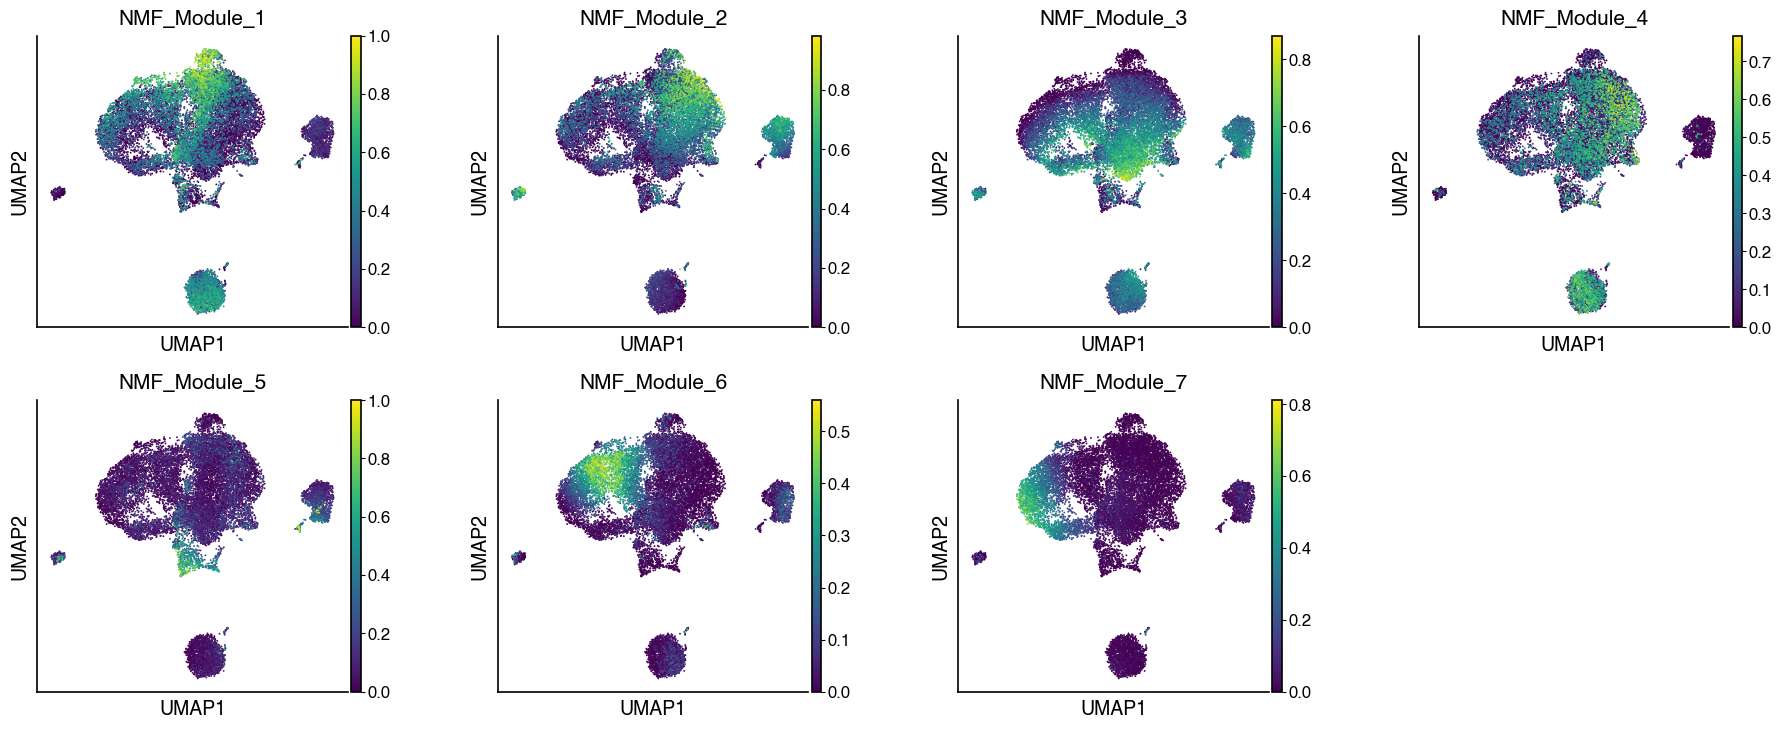

In [10]:
with mplscience.style_context():
    sc.pl.umap(adata, color = list(usage_norm.columns) , ncols = 4, wspace=0.35, show = False)
    # plt.savefig(os.path.join(plot_path, 'Extended_Figure_15c.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')
    plt.savefig(os.path.join(plot_path, 'reExtended_Figure_15c.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')
    plt.show()

In [21]:
rename_dict = {
    "Mouse1" : "Mouse1 (26W, F)",
    "Mouse2" : "Mouse2 (28W, M)",
    "Mouse3" : "Mouse3 (28W, F)",
    "Mouse4" : "Mouse4 (38W, F)",
}

adata.obs.sample_info = adata.obs.sample_info.replace(rename_dict)
adata.obs["sample_info"] = pd.Categorical(values=adata.obs["sample_info"].values, categories=rename_dict.values(), ordered=True)

In [87]:
# Create new ordered category list
new_categories = list(rename_dict.values())

# Create color mapping dictionary (category name → color)
color_mapping = {
    "Mouse1 (26W, F)": '#0081A7',
    "Mouse2 (28W, M)": '#00AFB9',
    "Mouse3 (28W, F)": '#FED9B7',
    "Mouse4 (38W, F)": '#F07167',
}

# Replace categories and set ordered=True
adata.obs.sample_info = adata.obs.sample_info.replace(rename_dict)
adata.obs["sample_info"] = pd.Categorical(values=adata.obs["sample_info"].values, 
                                         categories=new_categories, 
                                         ordered=True)

# Assign colors in the correct order based on the category order
adata.uns['sample_info_colors'] = [color_mapping[cat] for cat in new_categories]

KeyError: 'Control1'

In [23]:
adata.obs.sample_info = adata.obs.sample_info.cat.remove_unused_categories()

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


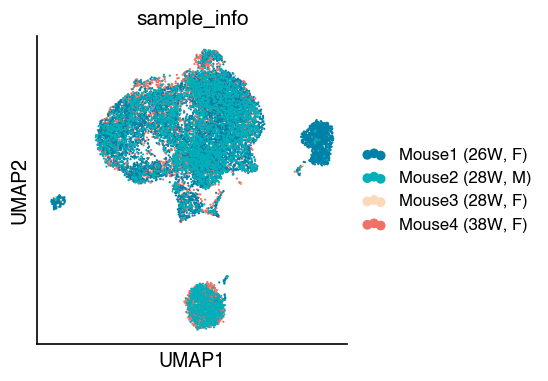

In [19]:
with mplscience.style_context():
    # sc.pl.umap(adata, color = ['cell_type', 'sample_id', 'grade'], show = False, wspace=0.4, ncols = 3)
    # sc.pl.umap(adata, color = ['sample_id'], show = False, wspace=0.4, ncols = 1, palette='tab20')
    sc.pl.umap(adata, color = ['sample_info'], show = False, wspace=0.4, ncols = 1, size = 10)
    # plt.savefig(os.path.join(plot_path, 'Extended_Figure_14b.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')
    plt.savefig(os.path.join(plot_path, 'reExtended_Figure_14b.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')
    plt.show()

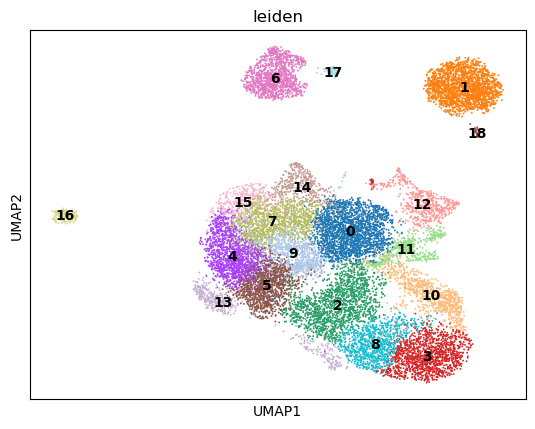

In [24]:
sc.pl.umap(adata, color = 'leiden', legend_loc = 'on data')

In [27]:
check = {
    "16" : "left",
    "6" : "up",
    "17" : "up",
    "1" : "right",
    "18" : "right"
}

adata.obs['leiden_check'] = adata.obs['leiden'].map(check)

In [28]:
bdata = sc.read_h5ad('../output/annotated_redo_2025.h5ad')

In [34]:
bdata.obs['leiden_check'] = bdata.obs.index.map(adata.obs.leiden_check)

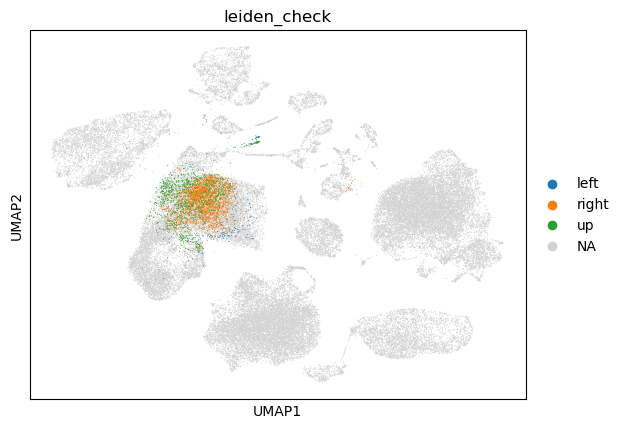

In [37]:
sc.pl.umap(bdata, color = ['leiden_check'])

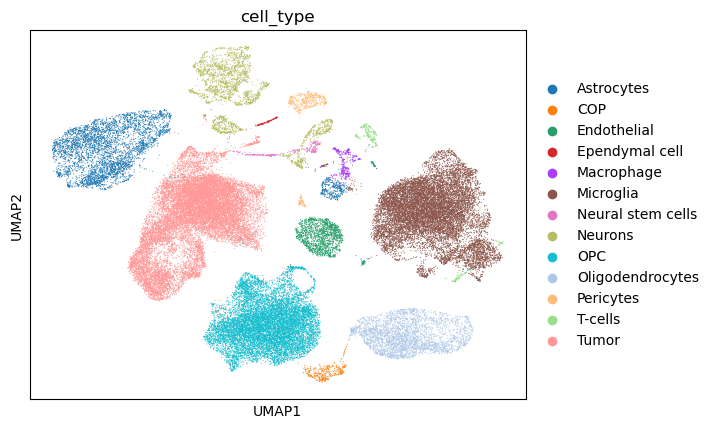

In [38]:
sc.pl.umap(bdata, color = 'cell_type')

## 1. Heatmap

In [11]:
topgenes.head(20)

,1,2,3,4,5,6,7
0,Sema6a,Dpp6,Txn2,Zfp260,Septin9,Dnmt1,Cenpe
1,9630014M24Rik,Tnr,Phb2,Pnpt1,Plekhg1,Clspn,Cenpf
2,Nav3,Myo5a,Park7,Zfp146,Limch1,Atad2,Dlgap5
3,Mtss1,Gm48091,Eif3e,Zfp74,Fzd1,Exo1,Aspm
4,Tafa5,Scn1a,Hddc2,Ifi213,Angpt2,Prim1,G2e3
5,Faxc,Slc9a9,Polr2e,Zfp566,Msn,Chaf1a,Ckap5
6,Eps15l1,Snhg14,Elob,Zfp27,Plod2,Pole,Tpx2
7,Ppp3ca,Tmem132d,Mrpl52,Zfp82,Tnc,Wdr76,Ccnb1
8,Sbf2,Scn3a,Wdr83os,Zfp383,Trim9,Mcm10,Cdc25b
9,Gad1os,Fry,Atp5pb,Clip3,Lhfp,Pcna,Kif2c


In [6]:
selected_genes = ["Hes1", "Foxd3", "Erbb3", "Plp1", "Ngfr", "Id3", "Ets1", "Cd44", "Sparc", "Anxa2", "Vim", "Sox10", # NCC
                  "Tnc", "Met", "Aldh1a3", "Nes", "Vgf", # MES
                  "Egfr", "Sox9", "Slc1a3", "Aldoc", "Ntsr2", # NSC
                  "Pdgfra", "Olig1", "Olig2", "C1ql1", "Cspg4", #OPC            
                  "Cd24a", "Sox11", "Sox4", "Dll3", "Stmn4", # NPC
                  "Fyn", "Enpp6", "Tnr", "Mink1", "Mbp", # OL
                  "Agt", "Gja1", "Aqp4", "Clu", "Apoe", # AC
                  "Mcm3", "Top2a", "Mki67", "Cdk1", # Cycling # "Mcm5", "Mcm7", 
                  ] # "Vcam1", "Olig2", "Tnr", "Slc1a2", "Ncam1", 'Sox2', 'Sox10','Gfap', 'Mog', 'Mag', 'Aldh1l1', 'Pdgfra', 'Notch', 'S100b', 'Cenpe', 'Vcam1', 'Apoe', 'Aldh1l1', 'Olig1', 'Apod', 'Sox4', 'Neurod1', 'Klf7', 'Cenph', 'Alodc', 'Neu4', 'Epn2', 'Nkx6-2', 'Fyn'

# selected_genes = ['Rpl15', 'Usf2', 'Tnr', 'Pdgfra', 'Olig2', 'Slc1a3', 'Apod', 'Alodc', 'Mcm3', 'Cdk1']

In [16]:
matrix = gep_scores.loc[top, :]

yticklabels = [gene if gene in selected_genes else '' for gene in matrix.index]
xticklabels = [gene if gene in selected_genes else '' for gene in matrix.index]
dist_matrix = pdist(matrix)
dist_square_matrix = squareform(dist_matrix)
linkage_matrix = linkage(dist_matrix, method='average')

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


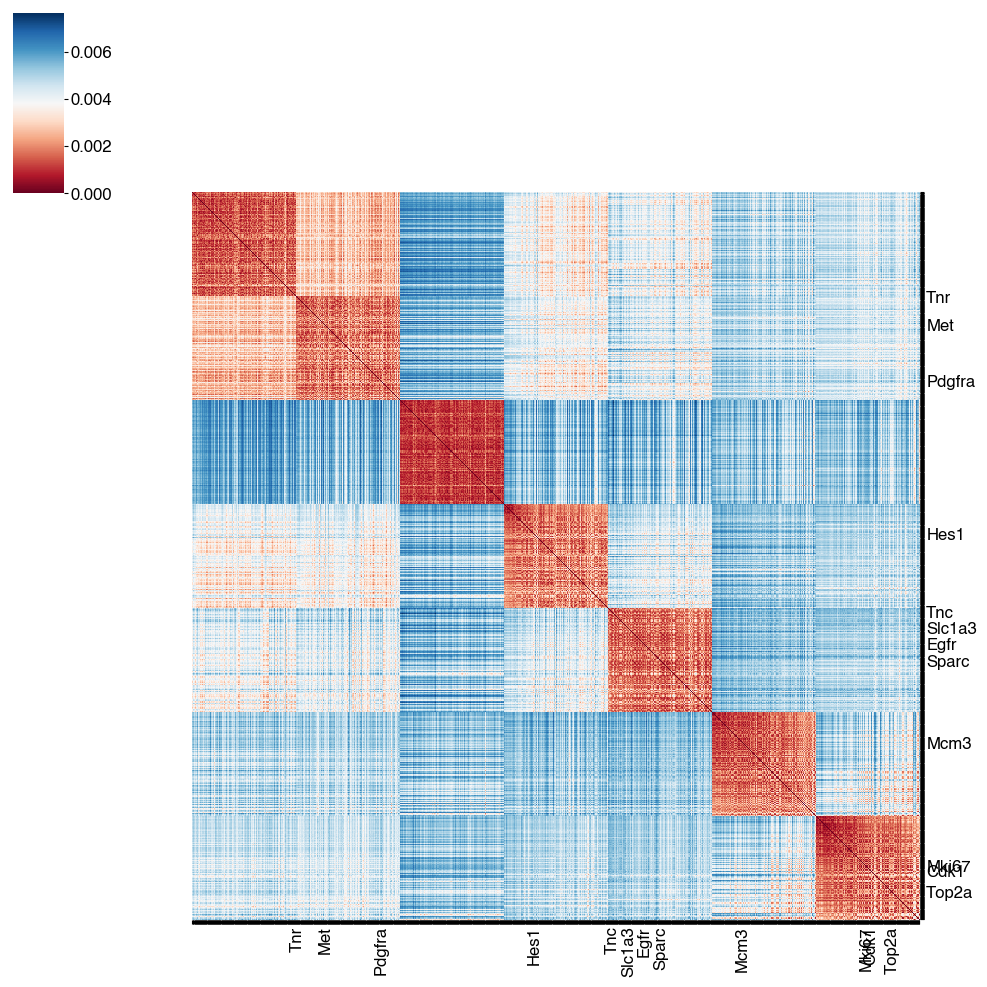

In [17]:
with mplscience.style_context(reset_current=True):
    g = sns.clustermap(dist_square_matrix, 
                row_cluster=False, 
                col_cluster=False, 
                cmap='RdBu', 
                xticklabels=xticklabels, 
                yticklabels=yticklabels, 
                rasterized=True,
                )
    ax = g.ax_heatmap
    ax.spines['right'].set_linewidth(0)
    ax.spines['bottom'].set_linewidth(0)
    ax.spines['left'].set_linewidth(0)
    ax.spines['top'].set_linewidth(0)

    plt.savefig(os.path.join(plot_path, f'Fig4b.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')
    plt.show()

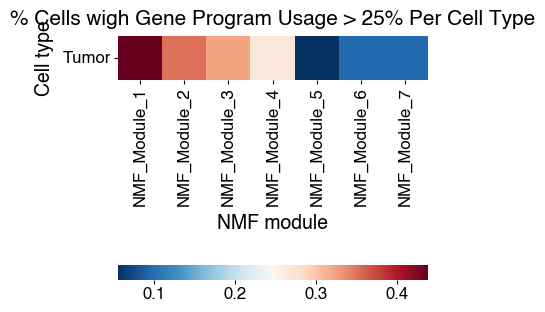

In [6]:
percent_group_usage = usage_norm.groupby(adata.obs['cell_type']).apply(lambda x: (x>0.25).mean())

with mplscience.style_context():
    ax = sns.heatmap(percent_group_usage, cmap = 'RdBu_r', cbar_kws = {'orientation': 'horizontal', 'pad': 0.6})
    ax.set_title('% Cells wigh Gene Program Usage > 25% Per Cell Type')
    ax.set_ylabel('Cell type')
    ax.yaxis.set_tick_params(rotation=0)
    ax.set_xlabel('NMF module')
    ax.set_aspect('equal')
    plt.show()

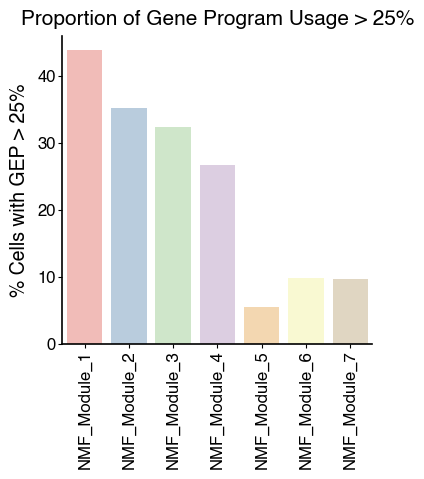

In [7]:

percent_usage = usage_norm.apply(lambda x: (x>0.25).mean())

with mplscience.style_context():
    ax = sns.barplot(percent_usage*100, palette='Pastel1')
    ax.set_title('Proportion of Gene Program Usage > 25%')
    ax.xaxis.set_tick_params(rotation=90)
    ax.set_ylabel('% Cells with GEP > 25%')
    # plt.savefig(os.path.join(plot_path, 'Fig4D_GEP_proportion_PerCell.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')
    plt.show()

# Revisded fig

In [ ]:
cell_max_gep = usage_norm.idxmax(axis = 1)
cell_max_usage = usage_norm.max(axis = 1)
per_topic_filter = {}
for module in sorted(set(cell_max_gep)):
    per_topic_filter[module] = (cell_max_gep == module)
    
second_gep_usage = usage_norm.values.copy()
for module in sorted(set(cell_max_gep)):
    second_gep_usage[per_topic_filter[module], int(module[-1]) -1] = 0
second_highest_gep = second_gep_usage.argsort(1)[:, -1]

In [ ]:
sample_palette = [color_mapping['Mouse1 (26W, F)'], 
                  color_mapping['Mouse2 (28W, M)'],
                  color_mapping['Mouse3 (28W, F)'],
                  color_mapping['Mouse4 (38W, F)']]

sample_palette

['#0081A7', '#00AFB9', '#FED9B7', '#F07167']

In [94]:
adata.uns['sample_info_colors'] = sample_palette

In [99]:
adata.obs.sample_info = adata.obs.sample_info.cat.remove_unused_categories()

In [105]:
sample_bar_colors

['#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F07167',
 '#F

In [104]:
import glasbey
import matplotlib.patches as mpatches

sample_info = adata.obs['sample_info']
# sample_palette = sns.color_palette('pastel', 5)
sample_color_dict = dict(zip(sample_info.cat.categories, sample_palette))
sample_legend_handles = [mpatches.Patch(color=sample_color_dict[sample], label=sample) for sample in sample_info.cat.categories]

fig, ax = plt.subplots(1, usage_norm.shape[1], figsize=(3, 4), dpi=300, 
                       gridspec_kw={'width_ratios': [1] * usage_norm.shape[1],
                                    'wspace': 0.1})

for i, module in enumerate(usage_norm.columns):
    # Get the ordering for this module
    i_order = np.where(per_topic_filter[module])[0][second_highest_gep[per_topic_filter[module]].argsort()]
    
    # Apply ordering to the data for visualization
    ordered_data = usage_norm.iloc[i_order]
    
    # Create the heatmap for this module
    im = ax[i].imshow(ordered_data.loc[:, usage_norm.columns].T,
                      aspect='auto', interpolation='nearest', cmap="cividis", vmin=0, vmax=1, rasterized=True)
    
    # Apply the SAME ordering to the sample info 
    ordered_samples = sample_info.iloc[i_order]
    sample_bar_colors = [sample_color_dict[sample] for sample in ordered_samples]
    
    # Create the color bar with the ordered samples
    ax_sample_bar = ax[i].inset_axes([0, 1.02, 1, 0.02])
    ax_sample_bar.imshow([sample_bar_colors], aspect='auto', interpolation='nearest')
    ax_sample_bar.set_xticks([])
    ax_sample_bar.set_yticks([])
    ax_sample_bar.spines['top'].set_visible(False)
    ax_sample_bar.spines['right'].set_visible(False)
    ax_sample_bar.spines['bottom'].set_visible(False)
    ax_sample_bar.spines['left'].set_visible(False)
    
    ax[i].set_title('')
    ax[i].set_xticks([])
    if i == 0:
        ax[i].set_yticks(range(len(usage_norm.columns)))
        ax[i].set_yticklabels(usage_norm.columns)
    else:
        ax[i].set_yticks([])

fig.suptitle('Heatmap of Gene Program x Cell', fontsize=12, y=1.05)
cax = fig.add_axes([0.24, 0.04, 0.12, 0.015])
cb = fig.colorbar(im, cax=cax, orientation='horizontal', ticks=[0, 0.5, 1.0])
cb.ax.xaxis.set_label_position('top')
cb.set_ticklabels(['0', '.5', '1'])
cb.ax.tick_params(labelsize=5, width=0.5, length=3)
cax.text(1.1, 0.5, 'Gene Expression', va='center', fontsize=6)

sample_legend_ax = fig.add_axes([0.1, -0.10, 0.35, 0.03])
sample_legend = sample_legend_ax.legend(handles=sample_legend_handles, loc='center', 
                                        ncol=len(sample_info.unique())//2, frameon=False)
sample_legend_ax.axis('off')

plt.savefig(os.path.join(plot_path, 'Fig4D_Heatmap(GEPxCell)_addedcbar.pdf'), 
            dpi=300, format='pdf', bbox_inches='tight')
plt.show()


TypeError: Image data of dtype <U7 cannot be converted to float

In [53]:
cell_max_gep = usage_norm.idxmax(axis = 1)
cell_max_usage = usage_norm.max(axis = 1)
per_topic_filter = {}
for module in sorted(set(cell_max_gep)):
    per_topic_filter[module] = (cell_max_gep == module)
    
second_gep_usage = usage_norm.values.copy()
for module in sorted(set(cell_max_gep)):
    second_gep_usage[per_topic_filter[module], int(module[-1]) -1] = 0
second_highest_gep = second_gep_usage.argsort(1)[:, -1]

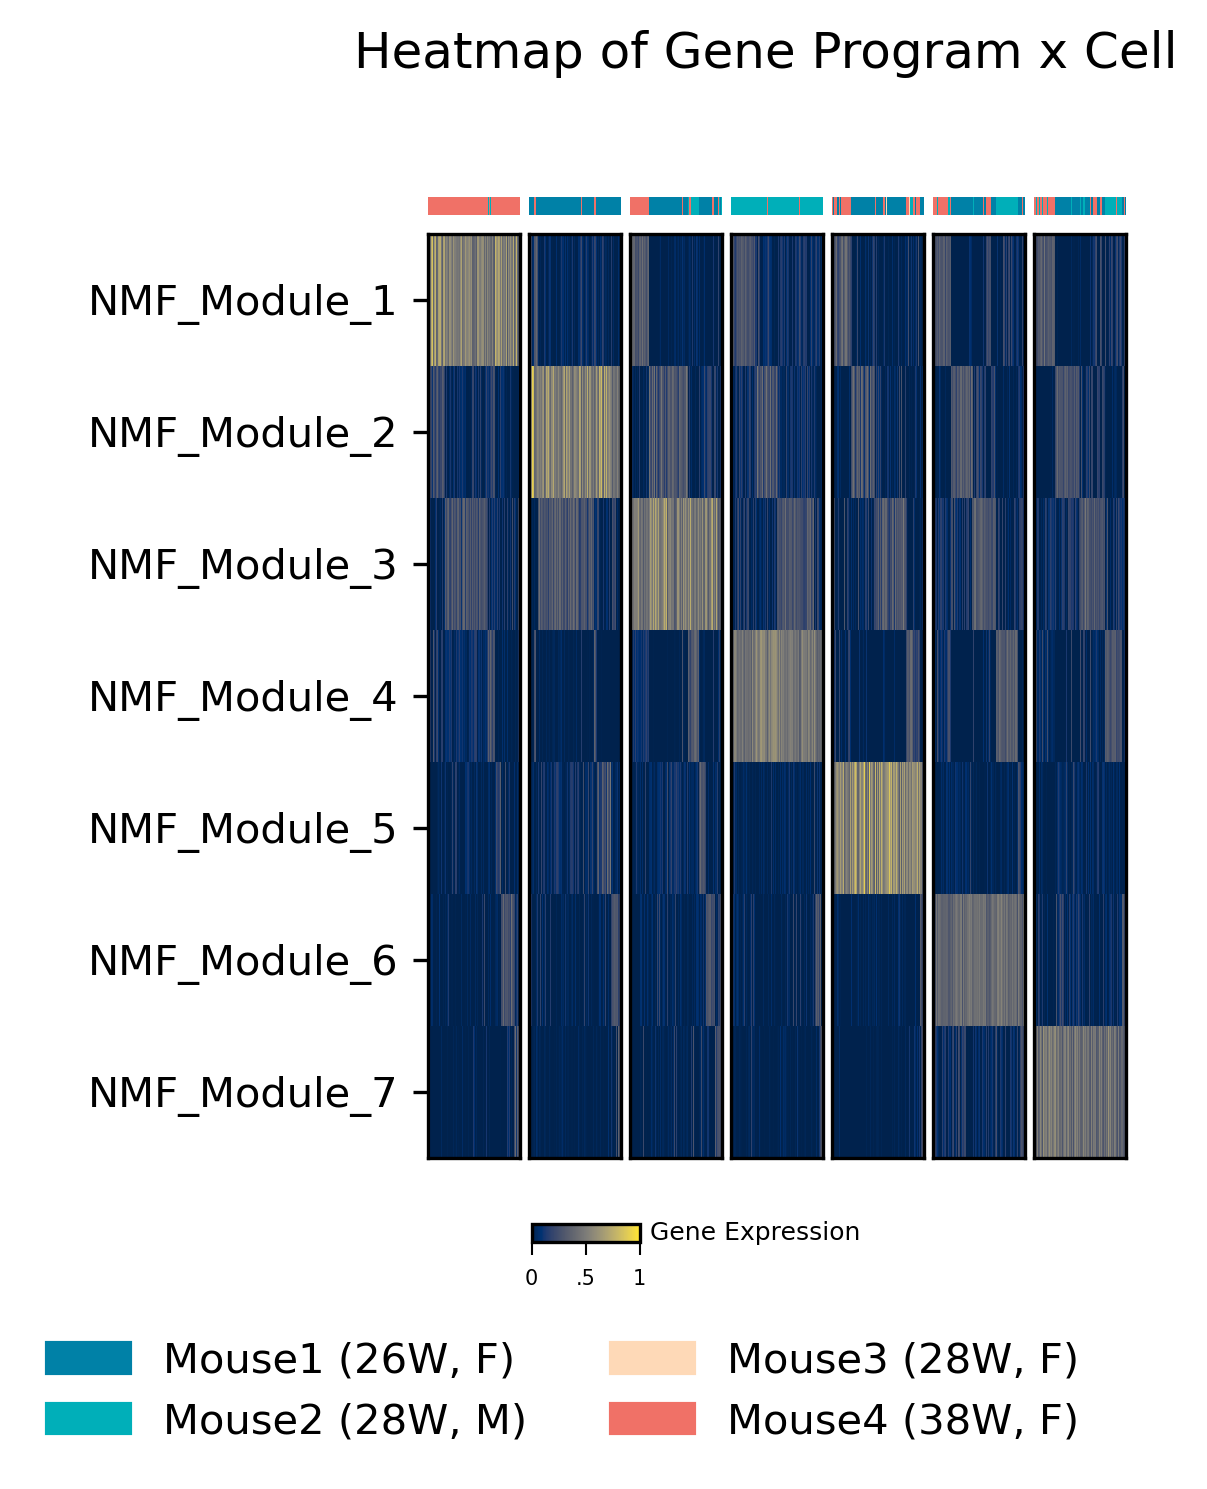

In [108]:
import matplotlib.colors as mcolors
import numpy as np
import glasbey
import matplotlib.patches as mpatches

sample_info = adata.obs['sample_info']
# sample_palette = sns.color_palette('pastel', 5)
sample_color_dict = dict(zip(sample_info.cat.categories, sample_palette))
sample_legend_handles = [mpatches.Patch(color=sample_color_dict[sample], label=sample) for sample in sample_info.cat.categories]

fig, ax = plt.subplots(1, usage_norm.shape[1], figsize=(3, 4), dpi=300, 
                       gridspec_kw={'width_ratios': [1] * usage_norm.shape[1],
                                    'wspace': 0.1})

for i, module in enumerate(usage_norm.columns):
    # Get the ordering for this module
    i_order = np.where(per_topic_filter[module])[0][second_highest_gep[per_topic_filter[module]].argsort()]
    
    # Apply ordering to the data for visualization
    ordered_data = usage_norm.iloc[i_order]
    
    # Create the heatmap for this module
    im = ax[i].imshow(ordered_data.loc[:, usage_norm.columns].T,
                      aspect='auto', interpolation='nearest', cmap="cividis", vmin=0, vmax=1, rasterized=True)
    
    # Apply the SAME ordering to the sample info 
    ordered_samples = sample_info.iloc[i_order]
    sample_bar_colors = [sample_color_dict[sample] for sample in ordered_samples]
    
    # Convert hex colors to RGB array for imshow
    sample_bar_rgb = np.array([mcolors.to_rgb(color) for color in sample_bar_colors])
    sample_bar_rgb = sample_bar_rgb.reshape(1, -1, 3)
    
    # Create the color bar with the ordered samples
    ax_sample_bar = ax[i].inset_axes([0, 1.02, 1, 0.02])
    ax_sample_bar.imshow(sample_bar_rgb, aspect='auto', interpolation='nearest')
    ax_sample_bar.set_xticks([])
    ax_sample_bar.set_yticks([])
    ax_sample_bar.spines['top'].set_visible(False)
    ax_sample_bar.spines['right'].set_visible(False)
    ax_sample_bar.spines['bottom'].set_visible(False)
    ax_sample_bar.spines['left'].set_visible(False)
    
    ax[i].set_title('')
    ax[i].set_xticks([])
    if i == 0:
        ax[i].set_yticks(range(len(usage_norm.columns)))
        ax[i].set_yticklabels(usage_norm.columns)
    else:
        ax[i].set_yticks([])

fig.suptitle('Heatmap of Gene Program x Cell', fontsize=12, y=1.05)
cax = fig.add_axes([0.24, 0.04, 0.12, 0.015])
cb = fig.colorbar(im, cax=cax, orientation='horizontal', ticks=[0, 0.5, 1.0])
cb.ax.xaxis.set_label_position('top')
cb.set_ticklabels(['0', '.5', '1'])
cb.ax.tick_params(labelsize=5, width=0.5, length=3)
cax.text(1.1, 0.5, 'Gene Expression', va='center', fontsize=6)

sample_legend_ax = fig.add_axes([0.1, -0.10, 0.35, 0.03])
sample_legend = sample_legend_ax.legend(handles=sample_legend_handles, loc='center', 
                                        ncol=len(sample_info.unique())//2, frameon=False)
sample_legend_ax.axis('off')

plt.savefig(os.path.join(plot_path, 'reFig4D_Heatmap(GEPxCell)_addedcbar.pdf'), 
            dpi=300, format='pdf', bbox_inches='tight')
plt.show()

# StarCAT

In [7]:
tcat = starcat.starCAT(reference = 'forNMF/tumor/cNMF/subcluster/subcluster.starcat_spectra.k_7.dt_0_5.txt', cachedir = '../tmp')

Using user specified reference spectra file forNMF/tumor/cNMF/subcluster/subcluster.starcat_spectra.k_7.dt_0_5.txt
No scores provided


## 1. Allen fetal

In [22]:
adata = sc.read_h5ad('../public/allen_fetal.h5ad')
adata = adata.raw.to_adata()
print(np.max(adata.X))
adata = adata[adata.obs['cell_type'] != 'cell'].copy()
sc.pp.filter_genes(adata, min_cells = 1)
adata.var['gene_id'] = adata.var_names
adata.var.index = adata.var['feature_name']

21954.0


In [23]:
mapper = {
    "GABAergic neuron": "neuron",
    "glutamatergic neuron": "neuron",
    "glioblast": "glioblast",
    "oligodendrocyte precursor cell": "oligodendrocyte precursor cell",
    "neural progenitor cell": "neural progenitor cell"
}

adata = adata[adata.obs['cell_type'].isin(['glioblast', 
       'neuron', 'GABAergic neuron',
       'glutamatergic neuron', 'oligodendrocyte precursor cell',
       'neural progenitor cell'])].copy()

adata.obs['cell_type'] = adata.obs['cell_type'].map(mapper).fillna(adata.obs['cell_type'])

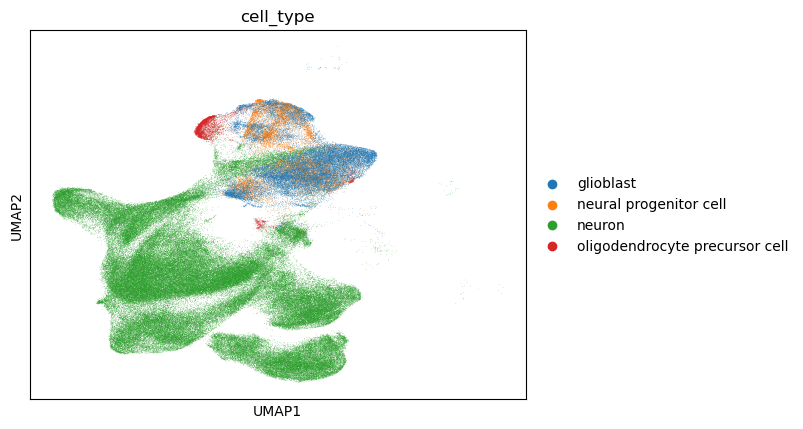

In [24]:
sc.pl.umap(adata, color = 'cell_type')

In [25]:
usage, _ = tcat.fit_transform(adata)
usage.columns = [f'NMF_Module_{i[3:]}' for i in usage.columns]
adata.obs = pd.merge(left=adata.obs, right=usage, how='left', left_index=True, right_index=True)

1942 out of 2000 genes in the reference overlap with the query


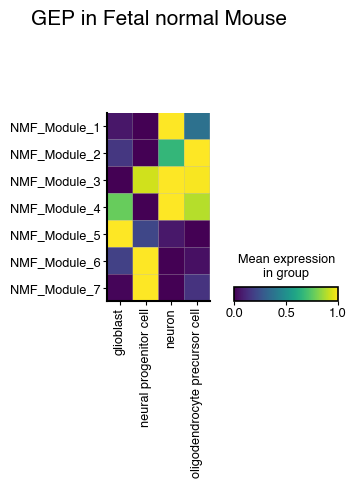

In [26]:
names = [t for t in adata.obs_keys() if t.startswith('NMF_Module')]

with mplscience.style_context():
    sc.pl.matrixplot(adata, names, groupby='cell_type', standard_scale='var', swap_axes=True, title = f"GEP in Fetal normal Mouse", )
    plt.show()

## 2. Allen Adult

In [ ]:
adata = sc.read_h5ad('../public/allen_adult.h5ad')
adata = adata.raw.to_adata()
print(np.max(adata.X))
adata = adata[adata.obs['cell_type'] != 'cell'].copy()
sc.pp.filter_genes(adata, min_cells = 1)
adata.var['gene_id'] = adata.var_names
adata.var.index = adata.var['feature_name']
adata.var

3304.0


,n_cells,feature_name,feature_reference,feature_biotype,feature_length,gene_id
feature_name,,,,,,
Xkr4,70141,Xkr4,NCBITaxon:10090,gene,6094,ENSMUSG00000051951
Rp1,474,Rp1,NCBITaxon:10090,gene,12311,ENSMUSG00000025900
Sox17,190,Sox17,NCBITaxon:10090,gene,4772,ENSMUSG00000025902
Mrpl15,15722,Mrpl15,NCBITaxon:10090,gene,8487,ENSMUSG00000033845
Lypla1,20587,Lypla1,NCBITaxon:10090,gene,7145,ENSMUSG00000025903
...,...,...,...,...,...,...
Uty,61,Uty,NCBITaxon:10090,gene,9791,ENSMUSG00000068457
Ddx3y,4,Ddx3y,NCBITaxon:10090,gene,5199,ENSMUSG00000069045
Usp9y,486,Usp9y,NCBITaxon:10090,gene,8094,ENSMUSG00000069044


In [44]:
mapper = {
    "inhibitory interneuron": "neuron",
    "medium spiny neuron": "neuron",
    "neuron": "neuron",
    "astrocyte": "astrocyte",
    "oligodendrocyte": "oligodendrocyte",
    "oligodendrocyte precursor cell": "oligodendrocyte precursor cell"
}

adata = adata[adata.obs['cell_type'].isin(['astrocyte', 'oligodendrocyte',
       'inhibitory interneuron', 'neuron',
       'oligodendrocyte precursor cell', 'medium spiny neuron'
       ])].copy()

adata.obs['cell_type'] = adata.obs['cell_type'].map(mapper).fillna(adata.obs['cell_type'])

In [ ]:
usage, _ = tcat.fit_transform(adata)
usage.columns = [f'NMF_Module_{i[3:]}' for i in usage.columns]
adata.obs = pd.merge(left=adata.obs, right=usage, how='left', left_index=True, right_index=True)

1844 out of 2000 genes in the reference overlap with the query


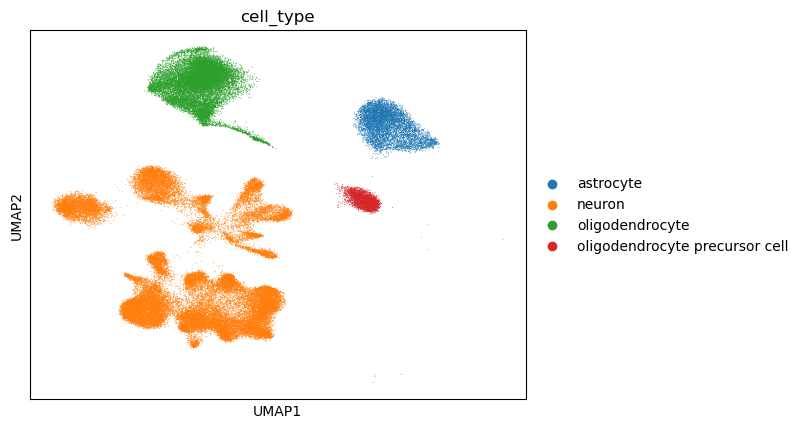

In [ ]:
sc.pl.umap(adata, color = 'cell_type')

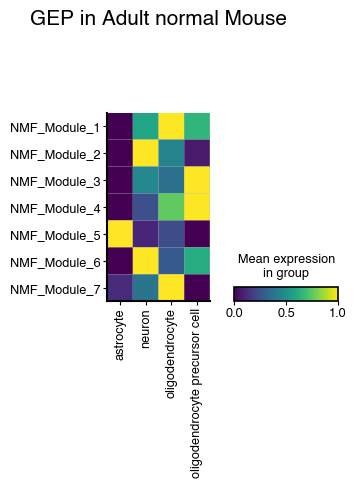

In [ ]:
names = [t for t in adata.obs_keys() if t.startswith('NMF_Module')]

with mplscience.style_context():
    sc.pl.matrixplot(adata, names, groupby='cell_type', standard_scale='var', swap_axes=True, title = f"GEP in Adult normal Mouse", )
    plt.show()

## 3. Enrique - Astrocytoma

In [14]:
adata = sc.read_h5ad('../public/translated/astrocytoma.h5ad')
adata

AnnData object with n_obs × n_vars = 56015 × 17177
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'orig.ident', 'seurat_clusters', 'grade', 'New_NMF_labelling'
    uns: 'neighbors'
    obsm: 'X_harmony', 'X_pca', 'X_tsne', 'X_umap'
    layers: 'counts'

In [15]:
adata = adata[adata.obs['New_NMF_labelling'].isin(['Astro-like', 'Cycling-like', 'OPC-like', 'RA'])].copy()

In [16]:
usage, _ = tcat.fit_transform(adata)
usage.columns = [f'NMF_Module_{i[3:]}' for i in usage.columns]
adata.obs = pd.merge(left=adata.obs, right=usage, how='left', left_index=True, right_index=True)

1725 out of 2000 genes in the reference overlap with the query


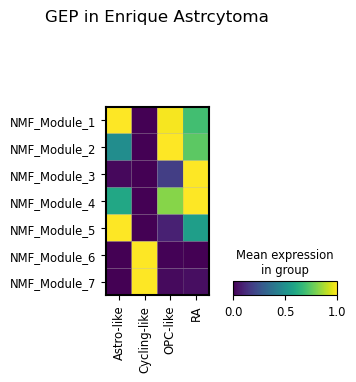

In [17]:
names = [t for t in adata.obs_keys() if t.startswith('NMF_Module')]

# with mplscience.style_context():
sc.pl.matrixplot(adata, names, groupby='New_NMF_labelling', standard_scale='var', swap_axes=True, title = f"GEP in Enrique Astrcytoma", cmap = 'viridis' , show = False)
plt.savefig(os.path.join(plot_path, 'Fig4c_human_AS.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')
plt.show()

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


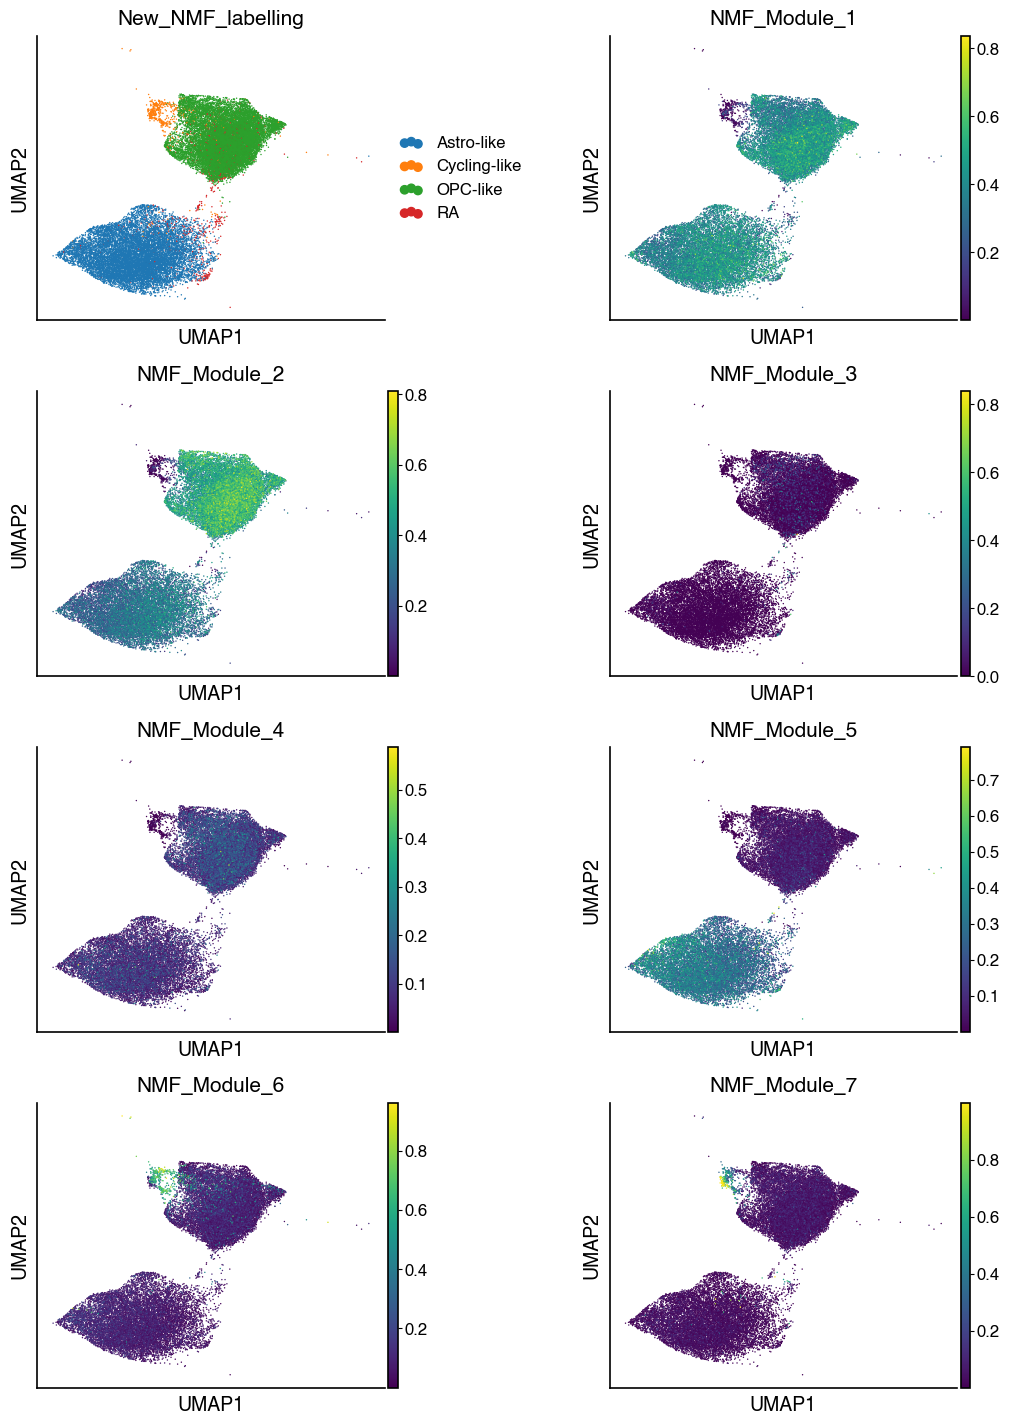

In [18]:
with mplscience.style_context():
    sc.pl.umap(adata, color = ['New_NMF_labelling'] + names, wspace= 0.5, ncols = 2, show = False)
    plt.savefig(os.path.join(plot_path, 'Fig4c_human_AS_UMAP.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')
    plt.show()


## 4. Enrique - Oligodendroglioma

In [19]:
adata = sc.read_h5ad('../public/translated/oligodendroglioma.h5ad')
adata

AnnData object with n_obs × n_vars = 64152 × 17124
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'orig.ident', 'seurat_clusters', 'grade', 'New_NMF_labelling'
    uns: 'neighbors'
    obsm: 'X_harmony', 'X_pca', 'X_umap'
    layers: 'counts'

In [21]:
adata = adata[adata.obs['New_NMF_labelling'].isin(['Astro-like', 'OPC-like', 'RA', 'Cycling-like'])].copy()

In [22]:
usage, _ = tcat.fit_transform(adata)
usage.columns = [f'NMF_Module_{i[3:]}' for i in usage.columns]
adata.obs = pd.merge(left=adata.obs, right=usage, how='left', left_index=True, right_index=True)

1728 out of 2000 genes in the reference overlap with the query


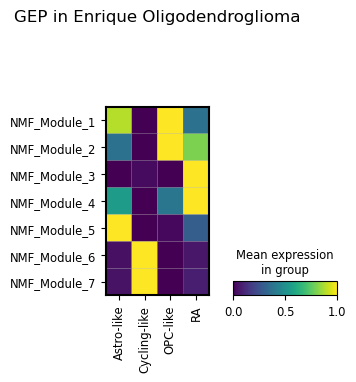

In [23]:
names = [t for t in adata.obs_keys() if t.startswith('NMF_Module')]

# with mplscience.style_context():
sc.pl.matrixplot(adata, names, groupby='New_NMF_labelling', standard_scale='var', swap_axes=True, title = f"GEP in Enrique Oligodendroglioma", cmap = 'viridis', show = False)
plt.savefig(os.path.join(plot_path, 'Fig4c_human_OD.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')
plt.show()

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


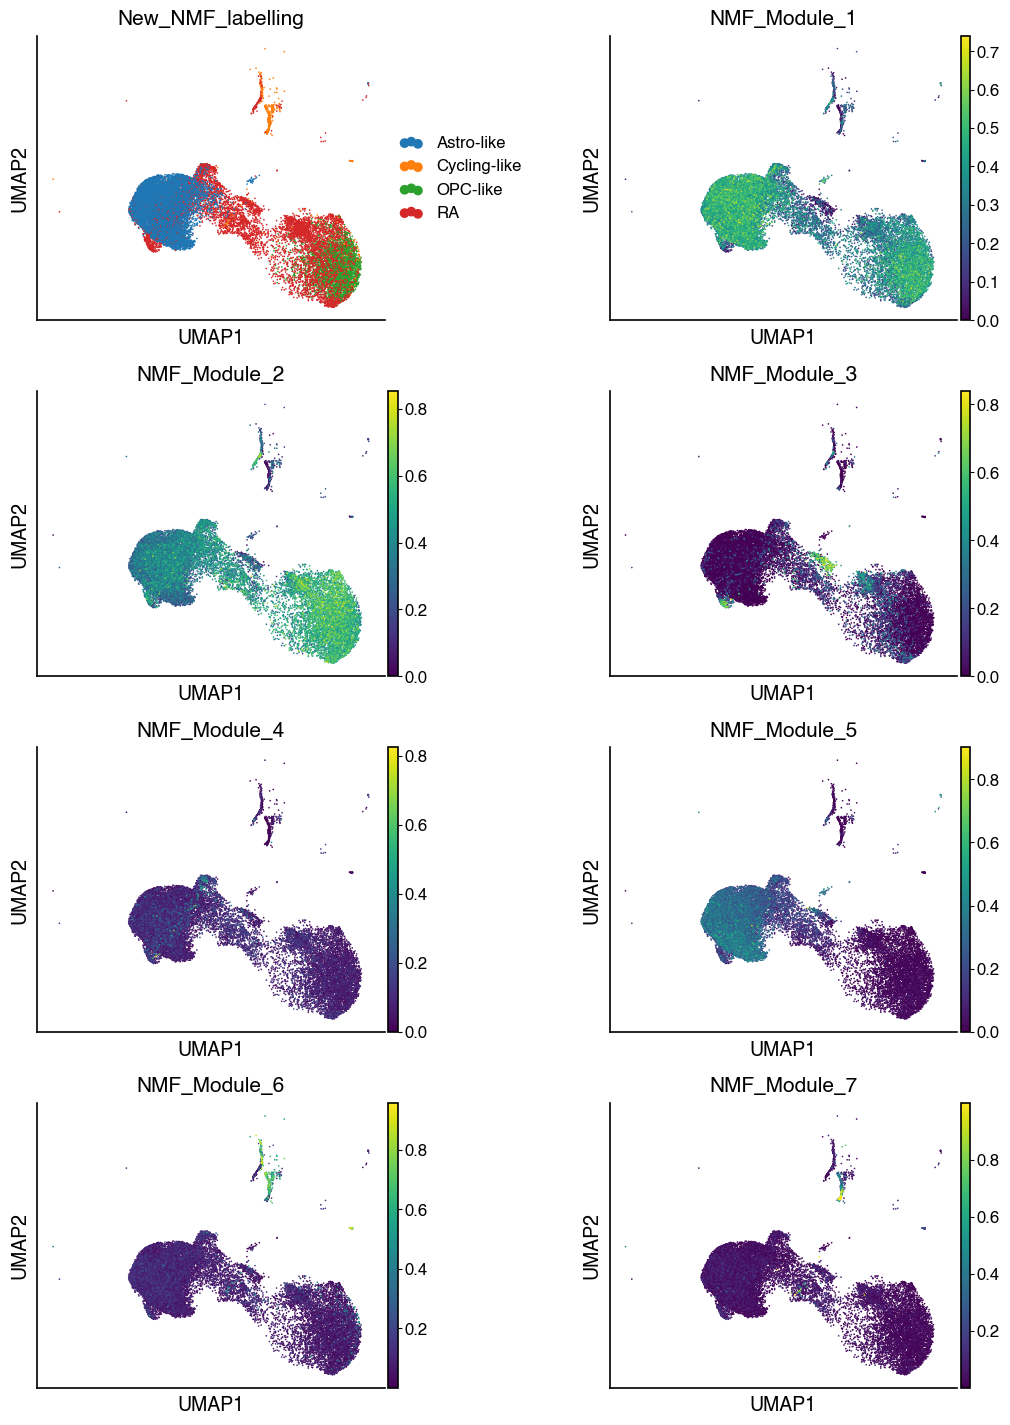

In [25]:
with mplscience.style_context():
    sc.pl.umap(adata, color = ['New_NMF_labelling'] + names, wspace= 0.5, ncols = 2, show = False)
    plt.savefig(os.path.join(plot_path, 'Fig4c_human_OD_UMAP.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')
    plt.show()

## 5. Tiroshi - Astrocytoma (GSE89567)

In [26]:
import pickle
with open('../output/tirosh_human_astrocytoma_translated.pkl', 'rb') as f:
    adata = pickle.load(f)

In [27]:
adata = adata[adata.obs.cell_type.isin(['OC-like', 'AC-like', 'stemness', ])].copy()

In [28]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)

In [29]:
usage, _ = tcat.fit_transform(adata)
usage.columns = [f'NMF_Module_{i[3:]}' for i in usage.columns]
adata.obs = pd.merge(left=adata.obs, right=usage, how='left', left_index=True, right_index=True)

1698 out of 2000 genes in the reference overlap with the query


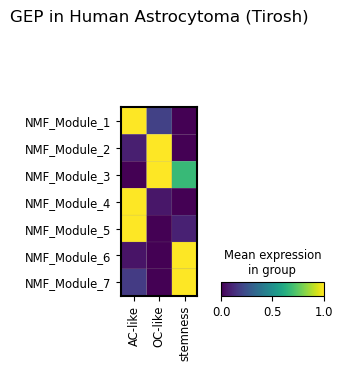

In [30]:
names = [t for t in adata.obs_keys() if t.startswith('NMF_Module')]


sc.pl.matrixplot(adata, names, groupby='cell_type', standard_scale='var', swap_axes=True, title = f"GEP in Human Astrocytoma (Tirosh)", cmap = 'viridis', show = False)
plt.savefig(os.path.join(plot_path, 'Fig4c_human_AS_Tirosh.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')
plt.show()

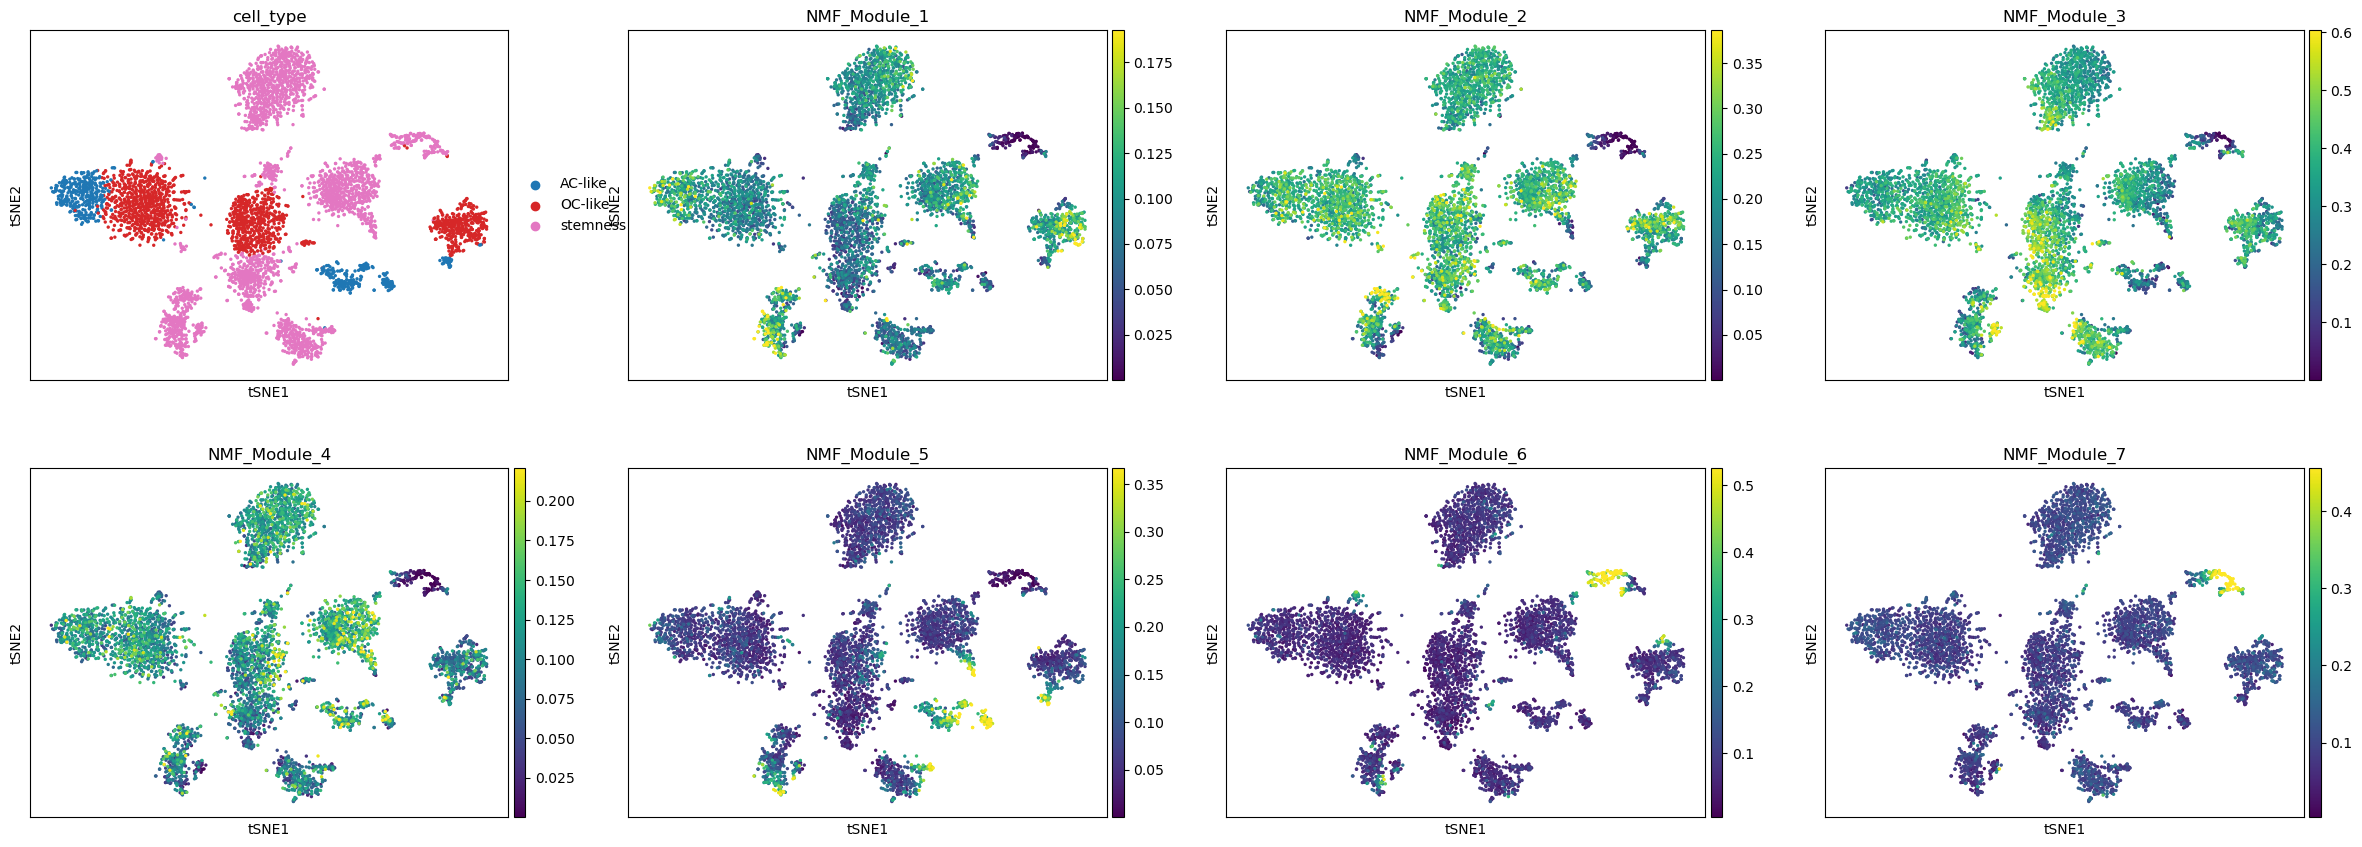

In [31]:
sc.tl.tsne(adata)
sc.pl.tsne(adata, color = ['cell_type'] + names, vmax = 'p99')

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


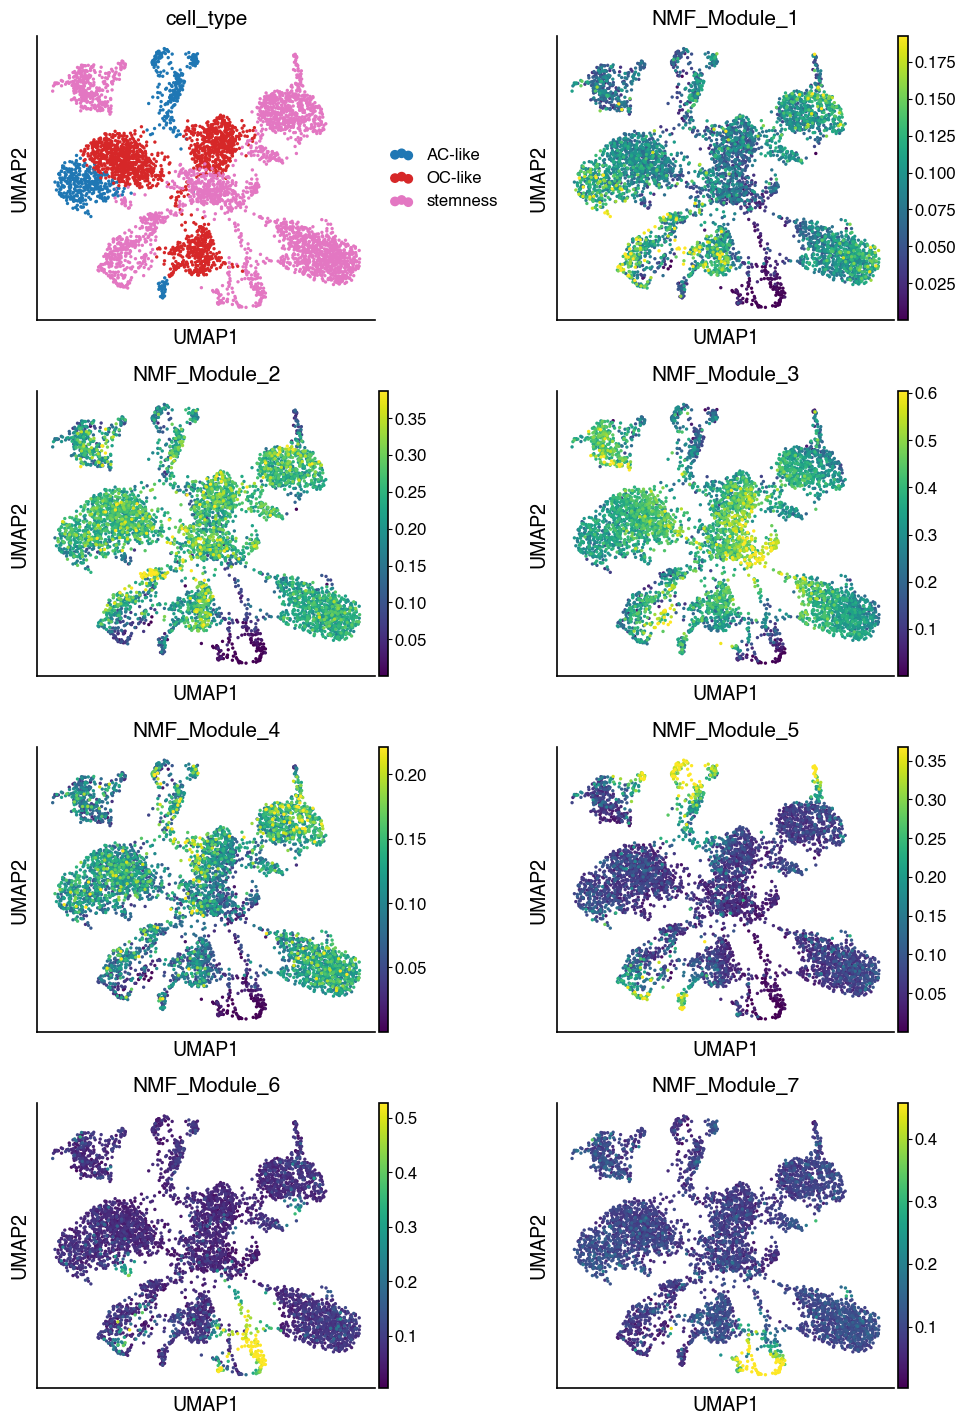

In [32]:
with mplscience.style_context():
    sc.pl.umap(adata, color = ['cell_type'] + names, vmax = 'p99', show = False, wspace=0.4, ncols = 2)
    plt.savefig(os.path.join(plot_path, 'Fig4c_human_AS_Tirosh_UMAP.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')
    plt.show()

## 6. Tiroshi - Oligodendroglioma (GSE70630)

In [33]:
with open('../output/tirosh_human_oligodendroglioma_translated.pkl', 'rb') as f:
    adata = pickle.load(f)

In [34]:
adata = adata[adata.obs.cell_type.isin(['OC-like', 'AC-like', 'stemness', ])].copy()

In [35]:
usage, _ = tcat.fit_transform(adata)
usage.columns = [f'NMF_Module_{i[3:]}' for i in usage.columns]
adata.obs = pd.merge(left=adata.obs, right=usage, how='left', left_index=True, right_index=True)

1698 out of 2000 genes in the reference overlap with the query


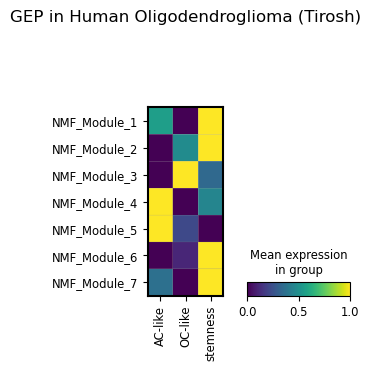

In [36]:
names = [t for t in adata.obs_keys() if t.startswith('NMF_Module')]

# with mplscience.style_context():
sc.pl.matrixplot(adata, names, groupby='cell_type', standard_scale='var', swap_axes=True, title = f"GEP in Human Oligodendroglioma (Tirosh)", cmap = 'viridis', show = False)
plt.savefig(os.path.join(plot_path, 'Fig4c_human_OD_Tirosh.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')
plt.show()

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


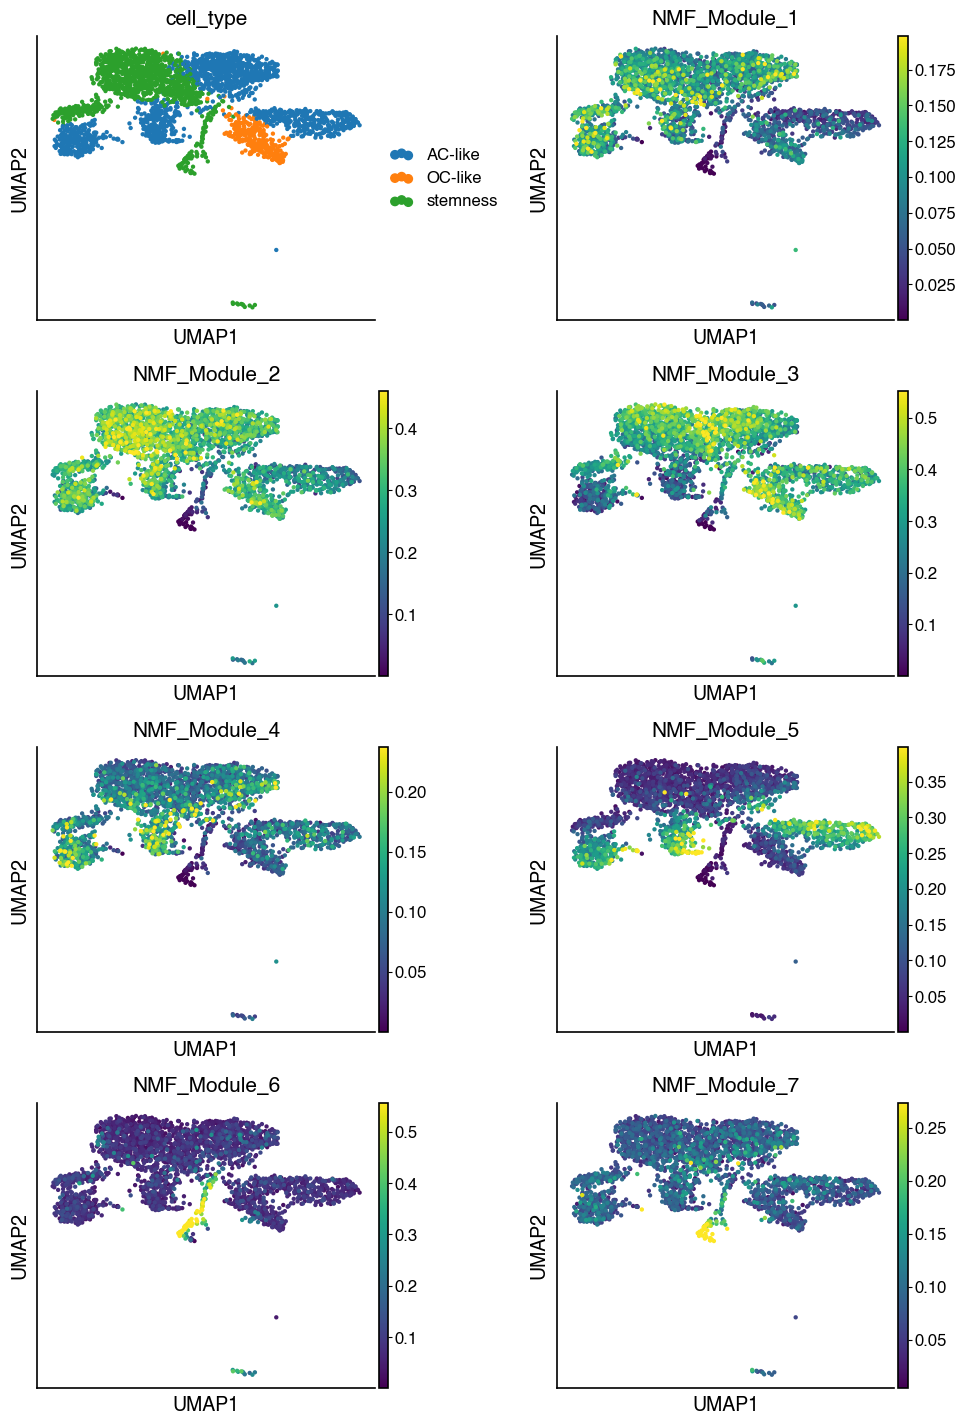

In [37]:
with mplscience.style_context():
    sc.pl.umap(adata, color = ['cell_type'] + names, vmax = 'p99', show = False, wspace=0.4, ncols = 2)
    plt.savefig(os.path.join(plot_path, 'Fig4c_human_OD_Tirosh_UMAP.pdf'), dpi = 300, format = 'pdf', bbox_inches='tight')
    plt.show()